# Recruitment Funnel & Hiring Process Optimization
### Python analysis notebook

**Business problem:** the company takes too long to hire, loses good candidates mid-process and spends heavily on some hiring channels. This notebook finds **where the funnel leaks, what slows it down, which sources are worth the money**, and estimates the gain from fixing the biggest bottleneck.

**Workflow:** Excel (first look) → SQL (database + business queries) → **Python (deeper analysis + model)** → Power BI (dashboard)

| # | Section |
|---|---|
| 1 | Load data from the SQL database |
| 2 | Data quality check |
| 3 | Headline KPIs |
| 4 | The funnel: where do candidates drop out? |
| 5 | Bottlenecks: which stages are slow? |
| 6 | Does slowness cost us candidates? |
| 7 | Source effectiveness: volume, cost and quality |
| 8 | Offers: why are they declined? (with a model) |
| 9 | Recruiters and trends |
| 10 | What-if: the value of a faster onsite stage |
| 11 | Export for Power BI |

## 1. Load data from the SQL database

In [1]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, classification_report

BASE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
IMG = BASE / "images"; IMG.mkdir(exist_ok=True)
pd.set_option("display.float_format", "{:,.2f}".format)

BLUE, ORANGE, AQUA, GRAY, INK = "#2a78d6", "#eb6834", "#1baf7a", "#b5b4ae", "#52514e"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.8, "axes.axisbelow": True,
                     "axes.titleweight": "bold", "axes.titlesize": 12, "axes.edgecolor": GRAY, "font.size": 10})
def save(fig, name):
    fig.tight_layout(); fig.savefig(IMG / f"{name}.png", dpi=150, bbox_inches="tight")

con = sqlite3.connect(BASE / "data" / "recruitment.db")
apps = pd.read_sql("SELECT * FROM vw_application_funnel", con,
                   parse_dates=["applied_date", "outcome_date", "start_date", "exit_date"])
reqs = pd.read_sql("SELECT * FROM vw_requisition_summary", con, parse_dates=["opened_date", "closed_date"])
events = pd.read_sql("SELECT e.*, a.applied_date FROM stage_events e JOIN applications a USING(application_id)",
                     con, parse_dates=["entered_date", "exited_date", "applied_date"])
spend = pd.read_sql("SELECT * FROM source_spend", con)
print(f"applications {apps.shape}, requisitions {reqs.shape}, stage events {events.shape}, spend rows {len(spend)}")
apps.head(3)

applications (34673, 43), requisitions (420, 15), stage events (52128, 10), spend rows 165


,application_id,candidate_id,requisition_id,source,applied_date,applied_month,current_stage,outcome,outcome_reason,outcome_date,...,days_in_process,offered_salary,offer_status,decline_reason,offer_vs_expected_pct,hire_id,start_date,employment_status,exit_date,performance_rating_6m
0,APP-204281,CAND-103928,REQ-1048,LinkedIn,2024-03-26,2024-03,Resume Screen,Rejected,Does not meet requirements,2024-03-27,...,1,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN
1,APP-212397,CAND-111394,REQ-1143,Job Boards,2024-08-14,2024-08,Resume Screen,Rejected,Does not meet requirements,2024-08-15,...,1,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN
2,APP-224387,CAND-122415,REQ-1285,Recruitment Agency,2025-04-06,2025-04,Resume Screen,Rejected,Does not meet requirements,2025-04-12,...,6,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN


## 2. Data quality check
Raw data was cleaned by `scripts/02_clean_data.py`; here is the log and a confirmation.

In [2]:
display(pd.read_csv(BASE / "data" / "clean" / "cleaning_log.csv").query("step != 'Loaded'"))
print("Duplicate application IDs:", apps.application_id.duplicated().sum())
print("Negative stage durations:", (events.days_in_stage < 0).sum())
print("Sources:", sorted(apps.source.unique()))

,table,step,rows_affected,detail
9,candidates,Converted salary text,666,'$95k' -> 95000
10,candidates,Filled missing gender,333,blank -> 'Not recorded' (kept separate from 'P...
11,applications,Removed duplicate rows,277,exact duplicate application records
12,applications,Standardised source names,1648,"e.g. 'linkedin', 'Linked In' -> 'LinkedIn'"
13,applications,Filled missing source,139,blank -> 'Unknown'
14,applications,Fixed date format,1040,MM/DD/YYYY text converted to a real date
15,stage_events,Removed duplicate rows,150,exact duplicate stage records
16,stage_events,Fixed swapped dates,77,exit date before entry date -> swapped back
17,applications,Final clean rows,34673,382 hires


Duplicate application IDs: 0
Negative stage durations: 0
Sources: ['Campus Recruiting', 'Company Website', 'Employee Referral', 'Job Boards', 'LinkedIn', 'Recruitment Agency', 'Social Media', 'Unknown']


## 3. Headline KPIs

In [3]:
hired = apps[apps.is_hired == 1]
decided = apps.offer_status.isin(["Accepted", "Declined"])
kpi = pd.Series({
    "Requisitions (positions)": f"{len(reqs)} ({reqs.headcount.sum()})",
    "Applications": f"{len(apps):,}",
    "Hires": f"{len(hired):,}",
    "Applications per hire": f"{len(apps)/len(hired):.0f}",
    "Avg time to hire (application -> accept)": f"{hired.time_to_hire_days.mean():.1f} days",
    "Avg time to fill (req opened -> filled)": f"{reqs.time_to_fill_days.mean():.1f} days",
    "Offer acceptance rate": f"{(apps.offer_status == 'Accepted').sum() / decided.sum():.1%}",
    "Requisition fill rate (closed reqs)": f"{(reqs.status == 'Filled').sum() / (reqs.status != 'Open').sum():.1%}",
    "Total recruiting spend": f"${spend.amount.sum():,.0f}",
    "Cost per hire": f"${spend.amount.sum() / len(hired):,.0f}",
})
kpi.to_frame("value")

,value
Requisitions (positions),420 (547)
Applications,"34,673"
Hires,382
Applications per hire,91
Avg time to hire (application -> accept),33.9 days
Avg time to fill (req opened -> filled),43.7 days
Offer acceptance rate,67.5%
Requisition fill rate (closed reqs),73.9%
Total recruiting spend,"$1,823,239"
Cost per hire,"$4,773"


**Reading the KPIs:** roughly 1 in 4 closed requisitions is cancelled unfilled, and about a third of offers are turned down. Those two numbers are the main targets for improvement.

## 4. The funnel — where do candidates drop out?

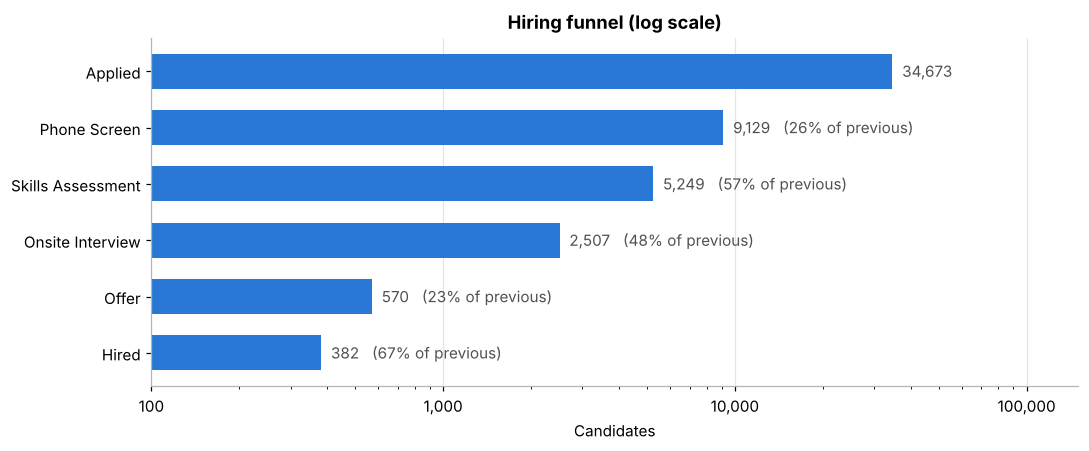

result,Passed,Accepted,Rejected,Withdrew,Declined
stage,,,,,
Resume Screen,26.3%,0.0%,73.2%,0.3%,0.0%
Phone Screen,57.5%,0.0%,36.4%,5.8%,0.0%
Skills Assessment,47.8%,0.0%,41.6%,10.4%,0.0%
Onsite Interview,22.7%,0.0%,61.4%,15.1%,0.0%
Offer,0.0%,67.0%,0.0%,0.0%,32.3%


In [4]:
funnel = pd.Series({
    "Applied": len(apps),
    "Phone Screen": apps.reached_phone_screen.sum(),
    "Skills Assessment": apps.reached_assessment.sum(),
    "Onsite Interview": apps.reached_onsite.sum(),
    "Offer": apps.reached_offer.sum(),
    "Hired": apps.is_hired.sum(),
})
conv = (funnel / funnel.shift(1)).fillna(1)

fig, ax = plt.subplots(figsize=(10, 4.2))
y = np.arange(len(funnel))[::-1]
ax.barh(y, funnel.values, color=BLUE, height=0.62)
ax.set_xscale("log"); ax.set_yticks(y, funnel.index); ax.grid(axis="y", visible=False)
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
for yi, (stage, n) in zip(y, funnel.items()):
    lab = f"{n:,}" + ("" if stage == "Applied" else f"   ({conv[stage]:.0%} of previous)")
    ax.text(n * 1.08, yi, lab, va="center", color=INK)
ax.set(title="Hiring funnel (log scale)", xlabel="Candidates", xlim=(100, 150000))
save(fig, "01_funnel"); plt.show()

stage_out = (events.groupby(["stage_order", "stage"]).result.value_counts(normalize=True)
             .unstack().fillna(0).droplevel(0))
stage_out[["Passed", "Accepted", "Rejected", "Withdrew", "Declined"]].style.format("{:.1%}")

**Insight — the funnel:**
- The **resume screen** removes ~3 in 4 applicants. That is expected, but it is also where low-quality sources (job boards, social media) waste recruiter time.
- The **onsite interview** has the lowest pass rate of the interview stages *and* the highest withdrawal rate — candidates who have already invested the most time are leaving.
- About **1 in 3 offers is declined**, the last and most expensive leak.

## 5. Bottlenecks — which stages are slow?

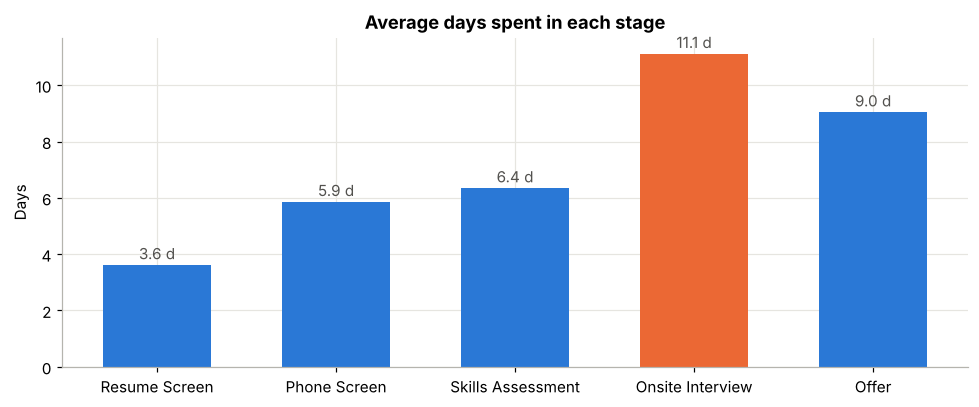

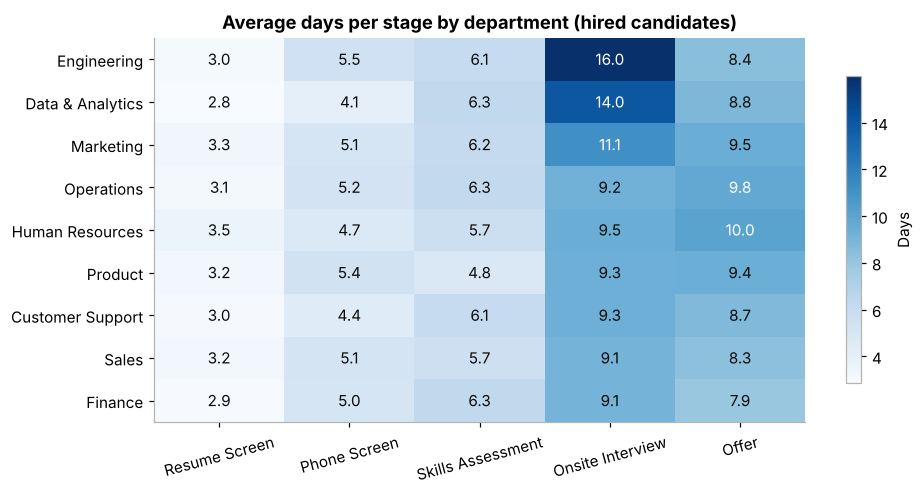

In [5]:
order = ["Resume Screen", "Phone Screen", "Skills Assessment", "Onsite Interview", "Offer"]
avg_days = events.dropna(subset=["days_in_stage"]).groupby("stage").days_in_stage.mean().reindex(order)

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.bar(order, avg_days, color=[ORANGE if s == "Onsite Interview" else BLUE for s in order], width=0.6)
for i, v in enumerate(avg_days): ax.text(i, v + 0.2, f"{v:.1f} d", ha="center", color=INK)
ax.set(title="Average days spent in each stage", ylabel="Days")
save(fig, "02_days_per_stage"); plt.show()

cols = ["days_resume_screen", "days_phone_screen", "days_assessment", "days_onsite", "days_offer"]
heat = hired.groupby("department_name")[cols].mean()
heat.columns = order
heat = heat.loc[heat.sum(axis=1).sort_values(ascending=False).index]
fig, ax = plt.subplots(figsize=(9, 4.6))
im = ax.imshow(heat.values, cmap="Blues", aspect="auto"); ax.grid(False)
ax.set_xticks(range(5), order, rotation=15); ax.set_yticks(range(len(heat)), heat.index)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        v = heat.values[i, j]
        ax.text(j, i, f"{v:.1f}", ha="center", va="center", color="white" if v > heat.values.max() * 0.6 else "#0b0b0b")
ax.set_title("Average days per stage by department (hired candidates)")
fig.colorbar(im, ax=ax, shrink=0.8, label="Days")
save(fig, "03_bottleneck_heatmap"); plt.show()

**Insight — bottleneck:** the **Onsite Interview** is the slowest stage (about 30% of total process time), and it is worst in **Engineering and Data & Analytics**, where panels of several interviewers have to be scheduled. The **Offer** stage (approvals + candidate decision) is the second slowest. Screening stages are quick.

## 6. Does slowness cost us candidates?

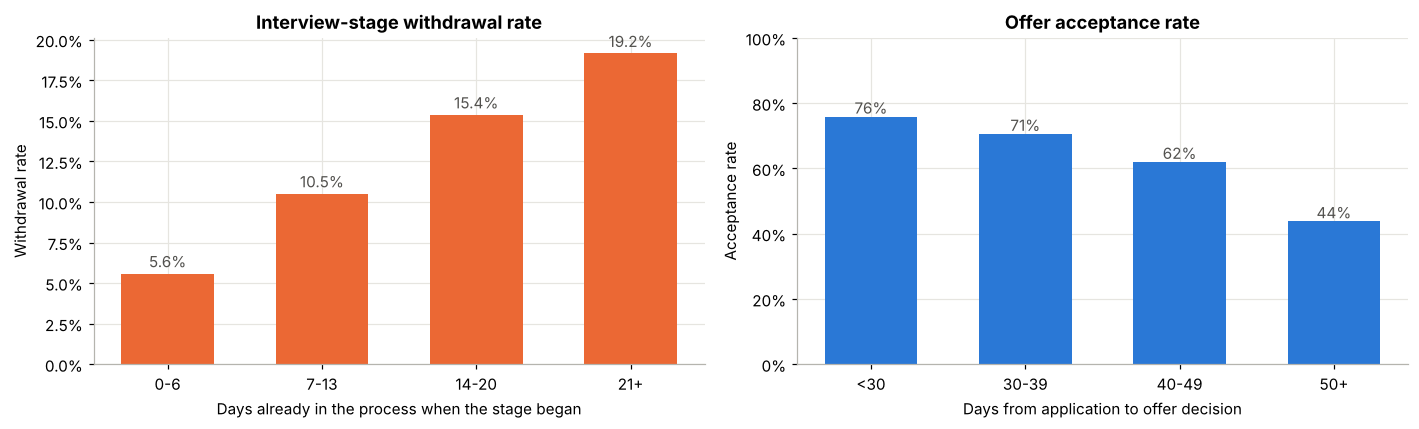

Candidates lost to speed (withdrew or declined because of another offer / slow process): 399
For comparison, total hires: 382


In [6]:
iv = events[events.stage.isin(["Phone Screen", "Skills Assessment", "Onsite Interview"])].copy()
iv["days_waiting"] = (iv.entered_date - iv.applied_date).dt.days
iv["band"] = pd.cut(iv.days_waiting, [-1, 6, 13, 20, 1000], labels=["0-6", "7-13", "14-20", "21+"])
w = iv.groupby("band", observed=True).result.apply(lambda s: (s == "Withdrew").mean())

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].bar(w.index.astype(str), w.values, color=ORANGE, width=0.6)
for i, v in enumerate(w): ax[0].text(i, v + 0.004, f"{v:.1%}", ha="center", color=INK)
ax[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax[0].set(title="Interview-stage withdrawal rate", xlabel="Days already in the process when the stage began",
          ylabel="Withdrawal rate")

off = apps[decided].copy()
off["accepted"] = (off.offer_status == "Accepted").astype(int)
off["days_band"] = pd.cut(off.days_in_process, [0, 29, 39, 49, 1000], labels=["<30", "30-39", "40-49", "50+"])
a = off.groupby("days_band", observed=True).accepted.mean()
ax[1].bar(a.index.astype(str), a.values, color=BLUE, width=0.6)
for i, v in enumerate(a): ax[1].text(i, v + 0.01, f"{v:.0%}", ha="center", color=INK)
ax[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0)); ax[1].set_ylim(0, 1)
ax[1].set(title="Offer acceptance rate", xlabel="Days from application to offer decision", ylabel="Acceptance rate")
save(fig, "04_delay_cost"); plt.show()

slow = apps.outcome_reason.isin(["Accepted another offer", "Process took too long"]) & apps.outcome.isin(["Withdrew", "Offer Declined"])
print(f"Candidates lost to speed (withdrew or declined because of another offer / slow process): {slow.sum()}")
print(f"For comparison, total hires: {len(hired)}")

**Insight — slowness is expensive:** a candidate who has already waited three weeks is **more than 3× as likely to withdraw** as one who has waited under a week, and offers made after 50+ days are accepted far less often. The top withdrawal reasons for slow processes are *"accepted another offer"* and *"process took too long"* — these are candidates the company wanted and lost to competitors.

## 7. Source effectiveness — volume, cost and quality

,applications,hires,resume_pass,time_to_hire,app_to_hire,spend,cost_per_hire,retained_12m,avg_performance
source,,,,,,,,,
Employee Referral,2567,96,49.9%,33.8,3.74%,"$242,500","$2,526",88%,3.60
Recruitment Agency,2297,53,46.0%,37.0,2.31%,"$1,150,400","$21,706",59%,3.33
Campus Recruiting,3167,36,33.5%,29.6,1.14%,"$85,960","$2,388",81%,3.00
Company Website,4730,52,24.5%,34.3,1.10%,"$23,766",$457,79%,3.28
LinkedIn,9539,100,28.1%,34.8,1.05%,"$169,392","$1,694",85%,3.06
Job Boards,10610,38,15.5%,32.2,0.36%,"$108,949","$2,867",76%,2.71
Social Media,1624,3,12.6%,27.7,0.18%,"$42,272","$14,091",nan%,nan


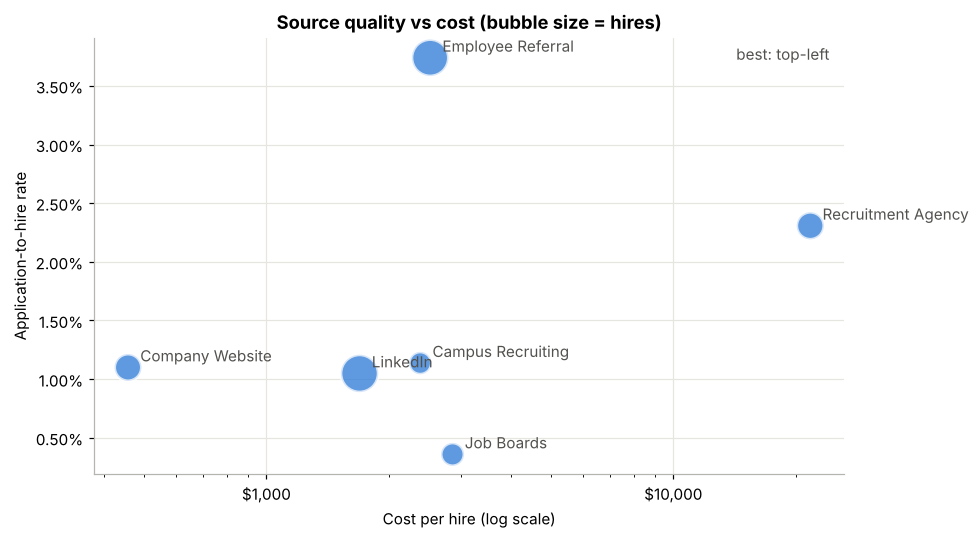

In [7]:
src = apps[apps.source != "Unknown"].groupby("source").agg(
    applications=("application_id", "size"), hires=("is_hired", "sum"),
    resume_pass=("reached_phone_screen", "mean"), time_to_hire=("time_to_hire_days", "mean"))
src["app_to_hire"] = src.hires / src.applications
src["spend"] = spend.groupby("source").amount.sum()
src["cost_per_hire"] = src.spend / src.hires
h12 = hired[hired.start_date <= "2024-12-31"].copy()
h12["retained_12m"] = h12.exit_date.isna() | ((h12.exit_date - h12.start_date).dt.days >= 365)
src["retained_12m"] = h12.groupby("source").retained_12m.mean()
src["avg_performance"] = hired.groupby("source").performance_rating_6m.mean()
src.loc[src.hires < 10, ["retained_12m", "avg_performance"]] = np.nan   # too few hires to judge
src = src.sort_values("app_to_hire", ascending=False)
display(src.style.format({"resume_pass": "{:.1%}", "app_to_hire": "{:.2%}", "spend": "${:,.0f}",
                          "cost_per_hire": "${:,.0f}", "retained_12m": "{:.0%}", "time_to_hire": "{:.1f}",
                          "avg_performance": "{:.2f}"}))

fig, ax = plt.subplots(figsize=(9, 5))
s = src[src.hires >= 10]
ax.scatter(s.cost_per_hire, s.app_to_hire, s=s.hires * 6, color=BLUE, alpha=0.75, edgecolor="white", linewidth=2)
for name, r in s.iterrows():
    ax.annotate(name, (r.cost_per_hire, r.app_to_hire), xytext=(8, 4), textcoords="offset points", color=INK)
ax.set_xscale("log"); ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set(title="Source quality vs cost (bubble size = hires)", xlabel="Cost per hire (log scale)",
       ylabel="Application-to-hire rate")
ax.text(0.98, 0.95, "best: top-left", transform=ax.transAxes, ha="right", color=INK)
save(fig, "05_source_cost_vs_conversion"); plt.show()

**Insight — sources:**
- **Employee referrals** are the standout: the highest conversion, among the best 12-month retention and performance, at a modest cost per hire (the referral bonus).
- **Job boards and social media** bring the most applicants but very few hires — high screening workload for little return.
- **Agencies** convert well but cost about 8× more per hire than referrals or job boards, and their hires are the most likely to leave in the first year.
- The **company careers site** is the cheapest channel per hire.

## 8. Offers — why are they declined?

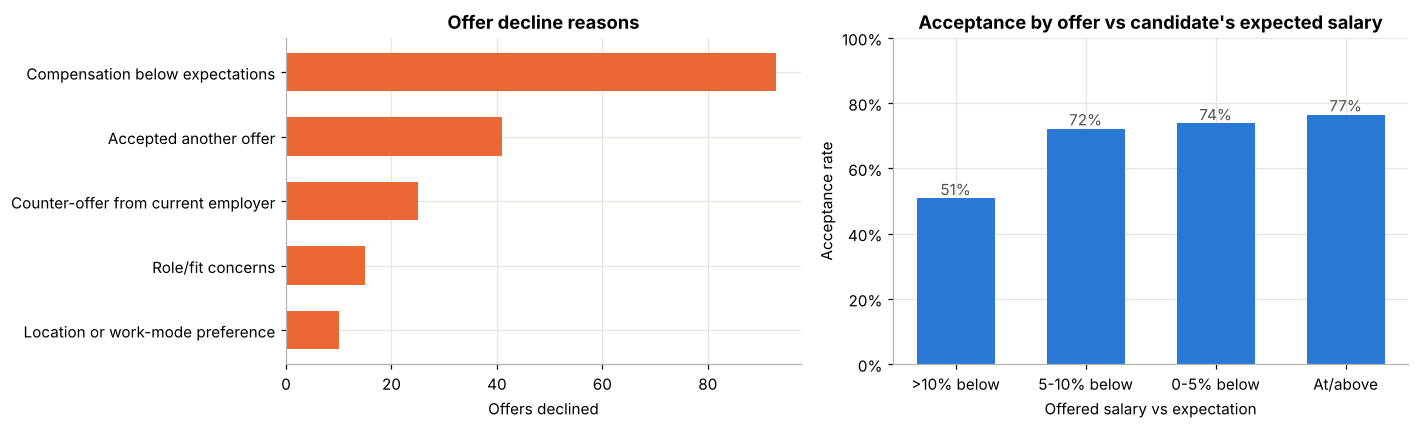

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
dr = apps.loc[apps.offer_status == "Declined", "decline_reason"].value_counts().sort_values()
ax[0].barh(dr.index, dr.values, color=ORANGE, height=0.6)
ax[0].set(title="Offer decline reasons", xlabel="Offers declined")

off["gap_band"] = pd.cut(off.offer_vs_expected_pct, [-1, -0.10, -0.05, -0.0001, 1],
                         labels=[">10% below", "5-10% below", "0-5% below", "At/above"])
g = off.groupby("gap_band", observed=True).accepted.mean()
ax[1].bar(g.index.astype(str), g.values, color=BLUE, width=0.6)
for i, v in enumerate(g): ax[1].text(i, v + 0.01, f"{v:.0%}", ha="center", color=INK)
ax[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0)); ax[1].set_ylim(0, 1)
ax[1].set(title="Acceptance by offer vs candidate's expected salary", xlabel="Offered salary vs expectation",
          ylabel="Acceptance rate")
save(fig, "06_offer_declines"); plt.show()

### Offer-acceptance model
Which factors predict whether a candidate accepts? A **logistic regression** is used because its coefficients are easy to explain to HR. A **random forest** is a check that we aren't missing non-linear effects. With only a few hundred offers, models are judged with **5-fold cross-validation**.

In [9]:
X = pd.DataFrame({
    "salary_gap_pct": off.offer_vs_expected_pct * 100,          # + = offer above expectation
    "days_in_process": off.days_in_process,
    "is_referral": (off.source == "Employee Referral").astype(int),
    "is_agency": (off.source == "Recruitment Agency").astype(int),
    "is_remote": (off.location == "Remote").astype(int),
    "is_sales": (off.department_name == "Sales").astype(int),
    "senior_or_lead": off.job_level.isin(["Senior", "Lead"]).astype(int),
})
y = off.accepted
cv = StratifiedKFold(5, shuffle=True, random_state=42)
logit = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
rf = RandomForestClassifier(n_estimators=400, min_samples_leaf=5, random_state=42)
p_log = cross_val_predict(logit, X, y, cv=cv, method="predict_proba")[:, 1]
p_rf = cross_val_predict(rf, X, y, cv=cv, method="predict_proba")[:, 1]
print(f"Cross-validated ROC-AUC  logistic regression: {roc_auc_score(y, p_log):.3f}   random forest: {roc_auc_score(y, p_rf):.3f}")
print(classification_report(y, (p_log >= 0.5).astype(int), target_names=["Declined", "Accepted"], digits=3))

# interpret the logistic model in plain units: odds multiplier per meaningful change
plain = make_pipeline(LogisticRegression(max_iter=2000)).fit(X, y)
coef = pd.Series(plain[-1].coef_[0], index=X.columns)
units = {"salary_gap_pct": 5, "days_in_process": 10}
eff = pd.DataFrame({"change": [f"+{units.get(c, 1)} {'pts' if c == 'salary_gap_pct' else 'days' if c == 'days_in_process' else '(yes vs no)'}" for c in coef.index],
                    "odds_multiplier": np.exp(coef * pd.Series(units).reindex(coef.index).fillna(1))})
eff.sort_values("odds_multiplier")

Cross-validated ROC-AUC  logistic regression: 0.736   random forest: 0.719
              precision    recall  f1-score   support

    Declined      0.680     0.359     0.470       184
    Accepted      0.748     0.919     0.825       382

    accuracy                          0.737       566
   macro avg      0.714     0.639     0.647       566
weighted avg      0.726     0.737     0.709       566



,change,odds_multiplier
is_sales,+1 (yes vs no),0.42
days_in_process,+10 days,0.61
is_agency,+1 (yes vs no),1.09
is_remote,+1 (yes vs no),1.14
senior_or_lead,+1 (yes vs no),1.20
salary_gap_pct,+5 pts,1.20
is_referral,+1 (yes vs no),2.45


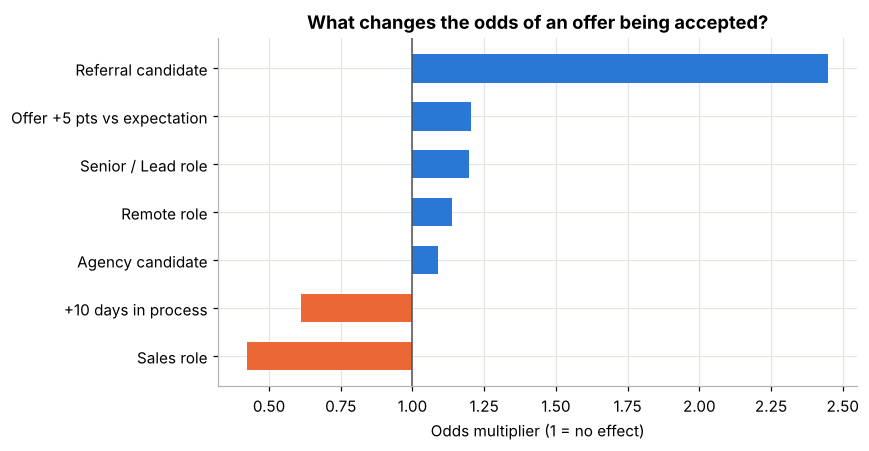

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.2))
e = eff.sort_values("odds_multiplier")
labels = {"salary_gap_pct": "Offer +5 pts vs expectation", "days_in_process": "+10 days in process",
          "is_referral": "Referral candidate", "is_agency": "Agency candidate", "is_remote": "Remote role",
          "is_sales": "Sales role", "senior_or_lead": "Senior / Lead role"}
ax.barh([labels[i] for i in e.index], e.odds_multiplier - 1, left=1,
        color=[BLUE if v >= 1 else ORANGE for v in e.odds_multiplier], height=0.6)
ax.axvline(1, color=INK, lw=1)
ax.set(title="What changes the odds of an offer being accepted?", xlabel="Odds multiplier (1 = no effect)")
save(fig, "07_offer_model_drivers"); plt.show()

**Insight — offers:** the model confirms the two levers the company controls: **pay relative to the candidate's expectation** and **speed**. Each extra 10 days in the process noticeably cuts the odds of acceptance, while matching salary expectations raises them. Referral candidates are much more likely to accept; Sales offers are the hardest to close.

## 9. Recruiters and trends

,requisitions,hires,time_to_hire,screen_days,fill_rate
recruiter_name,,,,,
Priya Nair,41,38,30.8,3.1,71%
Grace Chen,48,55,31.0,3.2,79%
Lucas Martin,62,64,31.2,3.7,85%
Hannah Cole,36,35,31.7,4.4,81%
Maya Patel,36,33,33.2,3.0,76%
Omar Haddad,45,37,35.0,3.3,72%
Sofia Ramirez,24,17,36.6,3.6,70%
Daniel Reyes,24,25,36.9,4.1,78%
Ethan Brooks,45,32,38.8,4.5,63%


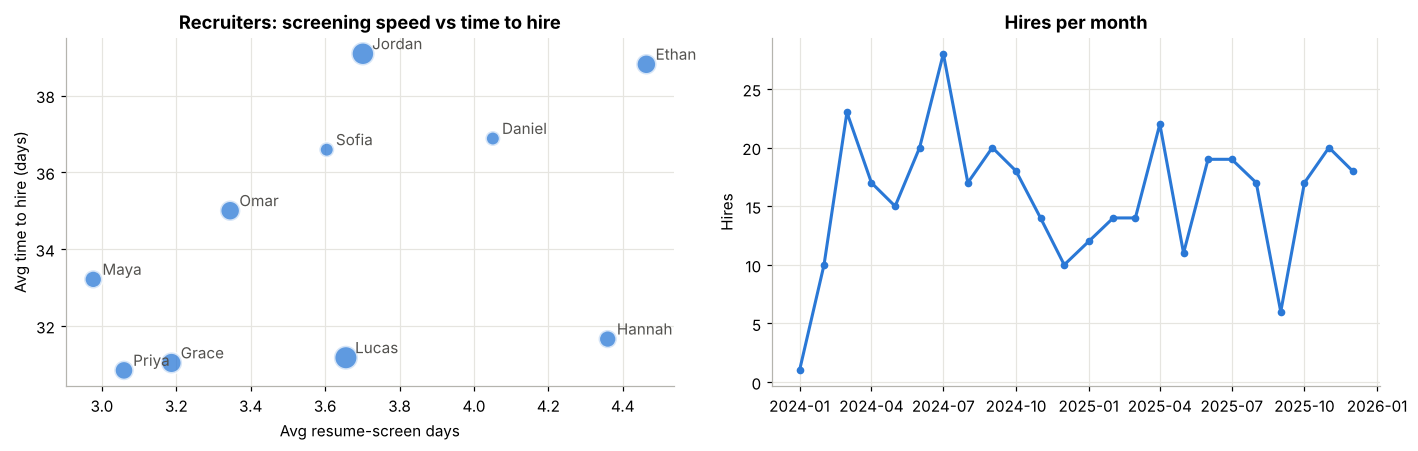

In [11]:
rec = apps.groupby("recruiter_name").agg(requisitions=("requisition_id", "nunique"), hires=("is_hired", "sum"),
                                         time_to_hire=("time_to_hire_days", "mean"),
                                         screen_days=("days_resume_screen", "mean"))
rec["fill_rate"] = reqs[reqs.status != "Open"].groupby("recruiter_name").status.apply(lambda s: (s == "Filled").mean())
display(rec.sort_values("time_to_hire").style.format({"time_to_hire": "{:.1f}", "screen_days": "{:.1f}", "fill_rate": "{:.0%}"}))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
ax[0].scatter(rec.screen_days, rec.time_to_hire, s=rec.requisitions * 4, color=BLUE, alpha=0.75, edgecolor="white", linewidth=2)
for n, r in rec.iterrows():
    ax[0].annotate(n.split()[0], (r.screen_days, r.time_to_hire), xytext=(6, 3), textcoords="offset points", color=INK)
ax[0].set(title="Recruiters: screening speed vs time to hire", xlabel="Avg resume-screen days",
          ylabel="Avg time to hire (days)")

m = hired.groupby(hired.outcome_date.dt.to_period("M")).size()
ax[1].plot(m.index.to_timestamp(), m.values, color=BLUE, lw=2, marker="o", ms=4)
ax[1].set(title="Hires per month", ylabel="Hires")
save(fig, "08_recruiters_and_trend"); plt.show()

**Insight — recruiters:** two recruiters stand out with the **longest time to hire (~39 days) and the lowest fill rate (63%)**: Ethan Brooks, the slowest first-screener, and Jordan Lee, who carries one of the two heaviest workloads (59 requisitions over two years vs. 24 for the lightest). Lucas Martin handles a similar load with fast results, so the fix is a mix of **rebalancing requisitions** and **sharing Lucas's and Priya's screening practices**.

## 10. What-if: the value of a faster onsite stage
The onsite stage takes ~11 days on average (≈16 in Engineering). Suppose the company introduces **pre-booked interview panel slots** and cuts onsite time by **5 days**. Using the relationships measured above:
1. a withdrawal model (logistic regression of withdrawal on days already waiting, by stage), and
2. the offer-acceptance model,

we re-score every candidate with 5 fewer days and estimate the extra hires.

In [12]:
from sklearn.linear_model import LogisticRegression as LR
iv2 = iv.copy()
iv2["withdrew"] = (iv2.result == "Withdrew").astype(int)
Xw = pd.get_dummies(iv2[["days_waiting", "stage"]], columns=["stage"], drop_first=True, dtype=int)
wmod = LR(max_iter=1000).fit(Xw, iv2.withdrew)

# 1) candidates who reached the offer stage would reach it 5 days sooner -> higher acceptance
X_fast = X.copy(); X_fast["days_in_process"] = (X_fast.days_in_process - 5).clip(lower=1)
p_now, p_fast = plain.predict_proba(X)[:, 1], plain.predict_proba(X_fast)[:, 1]
extra_accepts = p_fast.sum() - p_now.sum()

# 2) fewer onsite withdrawals: onsite candidates would have waited 5 fewer days by the time they withdrew/decided
onsite = iv2[iv2.stage == "Onsite Interview"]
Xo = Xw.loc[onsite.index]; Xo_fast = Xo.copy(); Xo_fast["days_waiting"] = (Xo_fast.days_waiting - 5).clip(lower=0)
saved_withdrawals = wmod.predict_proba(Xo)[:, 1].sum() - wmod.predict_proba(Xo_fast)[:, 1].sum()
# chance that an onsite candidate who does NOT withdraw ends up hired
onsite_to_hire = len(hired) / (len(onsite) - onsite.withdrew.sum())
extra_hires_from_withdrawals = saved_withdrawals * onsite_to_hire

years = 2
summary = pd.Series({
    "Extra accepted offers (2 yrs)": extra_accepts,
    "Onsite withdrawals avoided (2 yrs)": saved_withdrawals,
    "Extra hires from retained candidates (2 yrs, est.)": extra_hires_from_withdrawals,
    "Total extra hires per year (est.)": (extra_accepts + extra_hires_from_withdrawals) / years,
    "Value per year at current cost per hire ($)": (extra_accepts + extra_hires_from_withdrawals) / years
        * spend.amount.sum() / len(hired),
})
summary.to_frame("estimate").style.format("{:,.1f}")

,estimate
Extra accepted offers (2 yrs),25.3
Onsite withdrawals avoided (2 yrs),82.0
"Extra hires from retained candidates (2 yrs, est.)",14.7
Total extra hires per year (est.),20.0
Value per year at current cost per hire ($),"95,409.7"


**Reading the what-if:** these are *estimates* from simple models on historical data, not guarantees — but they show that speeding up one stage pays for itself: more accepted offers, fewer lost candidates, and fewer requisitions that have to be re-opened or filled through expensive agencies.

## 11. Export for Power BI

In [13]:
out = BASE / "data" / "powerbi"; out.mkdir(exist_ok=True)
fact_apps = apps.copy()
fact_apps["withdrew_flag"] = (fact_apps.outcome == "Withdrew").astype(int)
fact_apps["lost_to_speed_flag"] = slow.astype(int)
fact_apps.to_csv(out / "fact_applications.csv", index=False, date_format="%Y-%m-%d")
events.drop(columns="applied_date").to_csv(out / "fact_stage_events.csv", index=False, date_format="%Y-%m-%d")
reqs.to_csv(out / "fact_requisitions.csv", index=False, date_format="%Y-%m-%d")
spend.to_csv(out / "fact_source_spend.csv", index=False)
for t in ["departments", "recruiters", "candidates"]:
    pd.read_sql(f"SELECT * FROM {t}", con).to_csv(out / f"dim_{t}.csv", index=False)
funnel.rename_axis("stage").rename("candidates").reset_index().assign(step=range(1, 7)).to_csv(out / "funnel_summary.csv", index=False)
src.reset_index().to_csv(out / "source_scorecard.csv", index=False)
print(sorted(p.name for p in out.iterdir()))

['dim_candidates.csv', 'dim_departments.csv', 'dim_recruiters.csv', 'fact_applications.csv', 'fact_requisitions.csv', 'fact_source_spend.csv', 'fact_stage_events.csv', 'funnel_summary.csv', 'source_scorecard.csv']


## Summary of findings
| Question | Finding |
|---|---|
| **Where does the funnel leak?** | Resume screen (volume), onsite interview (lowest pass rate, highest withdrawals), and offers (~1 in 3 declined) |
| **What is slow?** | Onsite interview scheduling (~11 days; ~16 in Engineering), then offer approvals |
| **Does speed matter?** | Yes — withdrawals rise >3× after three weeks in process; offers after 50+ days are accepted far less |
| **Best sources?** | Referrals (conversion, retention, cost); careers site (cheapest). Job boards/social = volume with low yield; agencies = expensive |
| **Why are offers declined?** | Mostly pay below expectations, then competing offers |

### Recommendations
1. **Pre-book interview panels** (fixed weekly slots) to cut onsite time by ~5 days, starting with Engineering and Data & Analytics.
2. **Set a 30-day target** from application to offer and track it weekly on the Power BI dashboard.
3. **Collect salary expectations at the phone screen** and flag candidates whose expectation is above the band before the onsite.
4. **Grow the referral program** (bigger bonus, easier submission) and **shift job-board / social budget** towards it and the careers site; use agencies only for hard-to-fill Lead roles.
5. **Rebalance recruiter workload** (the busiest recruiters carry 2.5× the requisitions of the lightest) and pair slower recruiters with the fastest ones.